In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding,\
      plot_3d_points, numpy_to_torch, window_2d_sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from scipy.stats import wasserstein_distance


In [ ]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [ ]:
"persistence"

persistence    = PersistencePlotter(max_dim=1)
diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
diagrams_clean = persistence.remove_inf(diagrams_list)
entropy_array  = persistence.compute_entropy(diagrams_clean)
persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

print("Persistence array:", entropy_array)
print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

persistence.plot_persistence_diagrams(diagrams_list)
persistence.plot_entropy(entropy_array)
persistence.plot_persistence_image(persistence_images_list[1])  # H1
persistence.plot_betti_curves(betti_curves_array)


In [ ]:
"timedelay embeddings"

x  = np.linspace(0, 14*np.pi, 1000)
y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
plt.figure()
plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2')
plt.legend()
plt.show()

min_len = min(len(y1), len(y2))
y1, y2  = y1[:min_len], y2[:min_len]

time_delay, lag_dim = 20, 4
y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# time_delay2, lag_dim2 = 20, 4
y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
plt.figure()
# plt.scatter(y1_now, y1_delayed, s=4)
plt.scatter(y2_now, y2_delayed, s=4)
plt.show()

# persistence stuff
persistence  = PersistencePlotter(max_dim=1)
n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# y_data       = np.column_stack((y1_now, y1_delayed))
diagrams_list = persistence.compute_persistence_diagrams(y_all)
persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


X shape (15000, 2)
X_windows shape: (1139, 200, 2)
X_train/test shape: (911, 200, 2) (228, 200, 2)


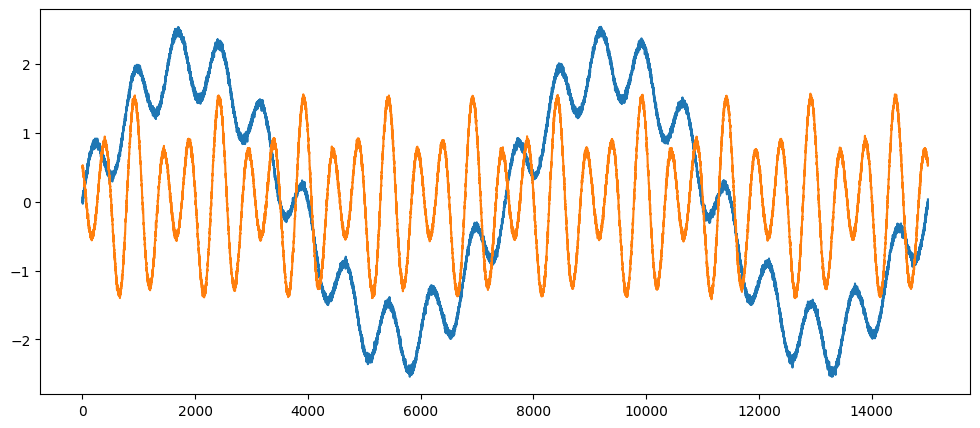

In [2]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 15_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = np.sin(timesteps) * ((0.5+0.5*timesteps) * np.sin(2*timesteps + 1)) + 0.03 * rng.normal(size=timesteps.shape)
X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

window_size     = 200
stride          = window_size//15
X_windows       = window_2d_sequence(X_scaled, window_size, stride)
X_train, X_test = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape)
print("X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')


Epoch 20/100, Loss: 0.0043
Epoch 40/100, Loss: 0.0026
Epoch 60/100, Loss: 0.0017
Epoch 80/100, Loss: 0.0016
Early stopping at epoch 85, loss = 0.0016


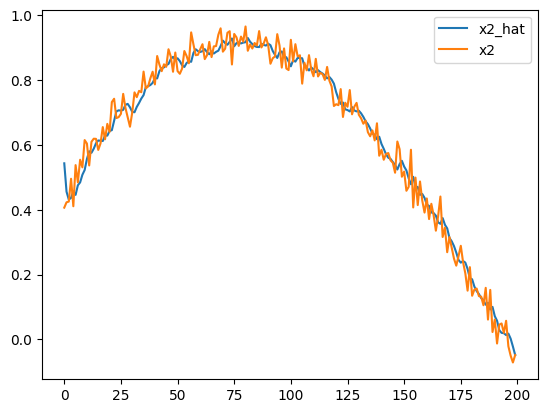

In [3]:
"train + eval LSTM encoder"

X_train, X_test    = numpy_to_torch(X_train), numpy_to_torch(X_test)
input_dim          = X_train.shape[-1]
latent_dim         = 8
encoder_hidden_dim = 56
decoder_hidden_dim = 56
lstm_ae            = LSTMAutoencoder(input_dim, latent_dim, encoder_hidden_dim=encoder_hidden_dim,
                             decoder_hidden_dim=decoder_hidden_dim, epochs=100, learning_rate=0.001)
losses             = lstm_ae.train_model(X_train, patience=12)
device             = lstm_ae.device

# inference:
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

# visual test that encoder works on x_test
window_number, feature_number = 2, 1
plt.plot(x_test_hat[window_number, :, feature_number].cpu(), label=f'x{window_number}_hat')
plt.plot(X_test[window_number, :, feature_number].cpu(), label=f'x{window_number}')
plt.legend()
plt.show()


z_train=torch.Size([911, 8]), z_windowed= torch.Size([115, 113, 8]), z_win_takens= (115, 93, 24)


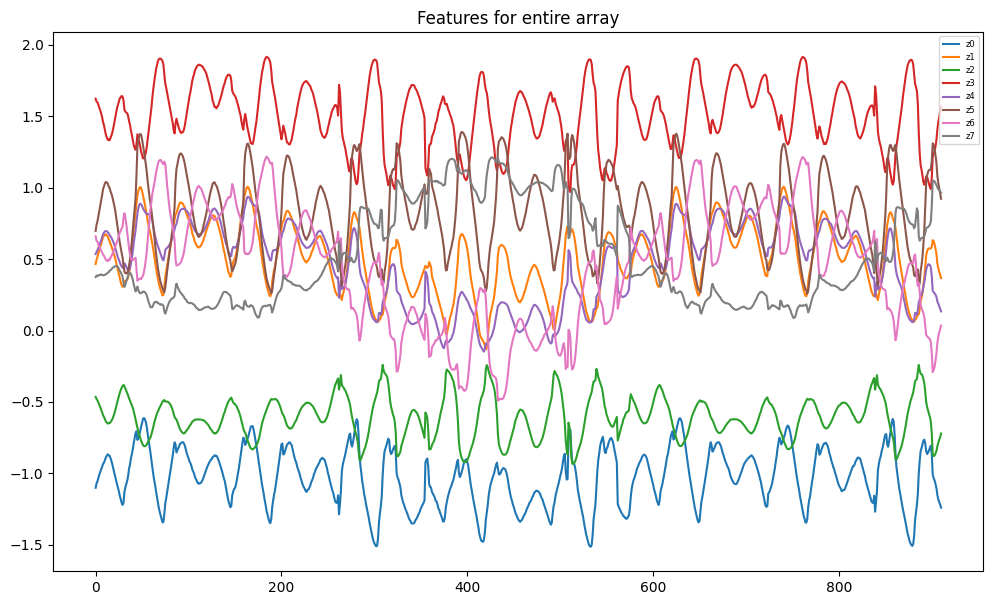

/tmp/ipykernel_3666658/1981802167.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88) # right-side colorbar


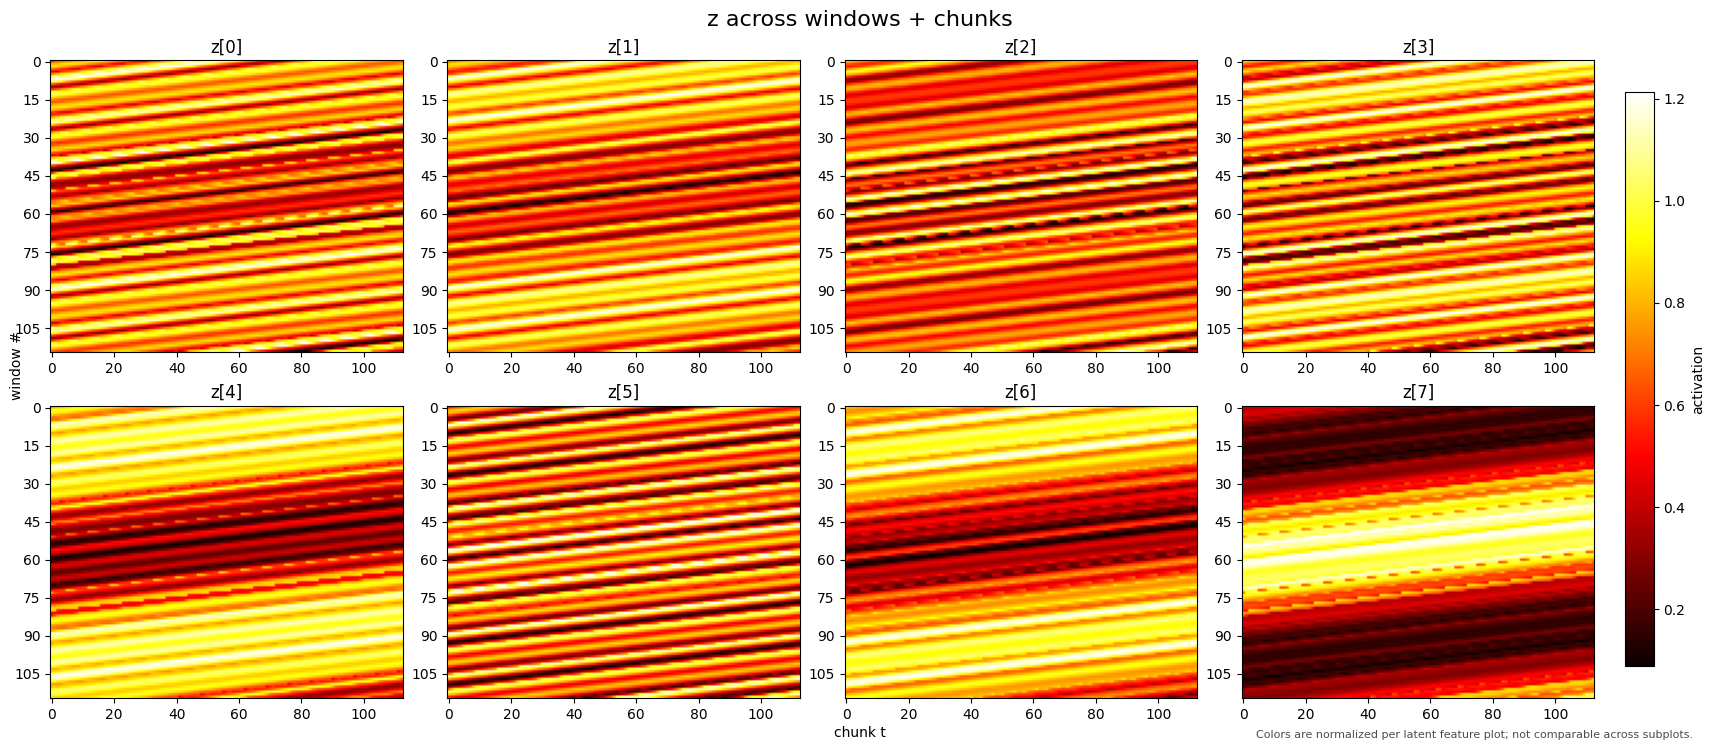

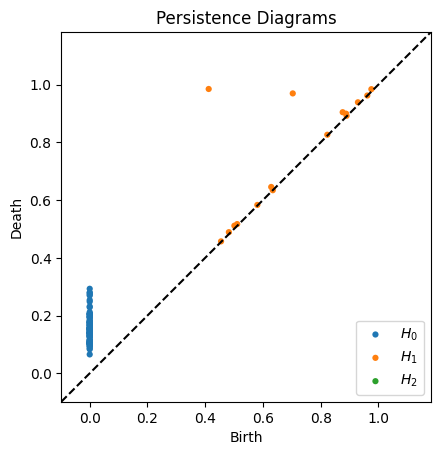

In [11]:
"plotting latents"
from matplotlib.ticker import MaxNLocator

z_window_size   = z_train.shape[0]//8
z_stride        = z_window_size//16
z_train_windows = window_2d_sequence(z_train, z_window_size, z_stride)

def plot_all_features_in_2d_array(dataset, window_number=0):
    """plots everything in 2d array. If array is 3d, plots features of a given input window"""
    plt.figure(figsize=(12, 7))

    # 3d array
    if dataset.ndim == 3 and dataset.shape[0] > 1:
        print(f"Plotting features for window {window_number} (dataset shape: {dataset.shape})")
        title = f"Features for window {window_number}"

        shape_idx_of_interest = 2 # 0 = windows, 1 = timesteps, 2 (or -1) = features
        for i in range(dataset.shape[shape_idx_of_interest]):
            plt.plot(dataset[window_number, :, i].cpu(), label=f'z{i}')

    # 2d array
    elif dataset.ndim == 2 or (dataset.ndim == 3 and dataset.shape[0] == 1):
        title = f"Features for entire array"

        shape_idx_of_interest = 1
        for i in range(dataset.shape[shape_idx_of_interest]):
            plt.plot(dataset[:, i].cpu(), label=f'z{i}')

    plt.title(title)
    plt.legend(fontsize=6)
    plt.show()

def plot_latent_evolution_grid(z: np.ndarray | torch.Tensor, max_latent_dims: int = 8, n_plots_per_row: int = 4):
    """Given 3D array, plot Heatmaps for latent tensors (W, C, L) as per-dimension heatmaps in a grid.
    Args:
        z: (W, C, L) array or tensor.
        max_latent_dims: max L to plot.
        n_plots_per_row: grid width.
    Note: Each subplot is independently scaled."""

    if isinstance(z, torch.Tensor):
        z = z.detach().cpu().numpy()

    L     = min(z.shape[2], max_latent_dims)
    nrows = int(np.ceil(L / n_plots_per_row))
    
    fig, axes = plt.subplots(
        nrows,
        n_plots_per_row,
        figsize=(4 * n_plots_per_row + 1, 3.6 * nrows),
        constrained_layout=True)
    axes = axes.flatten()

    im = None
    for i in range(L):
        im = axes[i].imshow(z[:, :, i], aspect='auto', cmap='hot')
        axes[i].set_title(f"z[{i}]")
        axes[i].yaxis.set_major_locator(MaxNLocator(integer=True))

        # remove per-plot axis labels
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(L, len(axes)):
        axes[j].axis('off')

    fig.subplots_adjust(right=0.88) # right-side colorbar

    cbar = fig.colorbar(
        im,
        ax=axes[:L],
        orientation='vertical',
        fraction=0.03,
        pad=0.02,
        shrink=0.9)
    cbar.set_label("activation")

    # global axis labels
    fig.text(0.5, -0.02, "chunk t", ha='center', va='bottom')
    fig.text(0.0, 0.5, "window #", va='center', rotation='vertical')

    # note
    fig.text(
        0.99,
        -0.02,
        "Colors are normalized per latent feature plot; not comparable across subplots.",
        ha='right',
        va='bottom',
        fontsize=8,
        alpha=0.7)

    fig.suptitle("z across windows + chunks", fontsize=16)
    plt.show()

takens_obj = TakensEmbedding(delay=10, embedding_dim=3)
z_takens   = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
plotter    = PersistencePlotter(max_dim=2, pixel_size=0.2)
dgms       = plotter.remove_inf(plotter.compute_persistence_diagrams(z_takens[0]))

print(f"z_train={z_train.shape}, z_windowed= {z_train_windows.shape}, z_win_takens= {z_takens.shape}")

plot_all_features_in_2d_array(z_train, window_number=1)
plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)
plotter.plot_persistence_diagrams(dgms)

# A(t) = mean_k corr(z[:,k], z[:,k+τ])


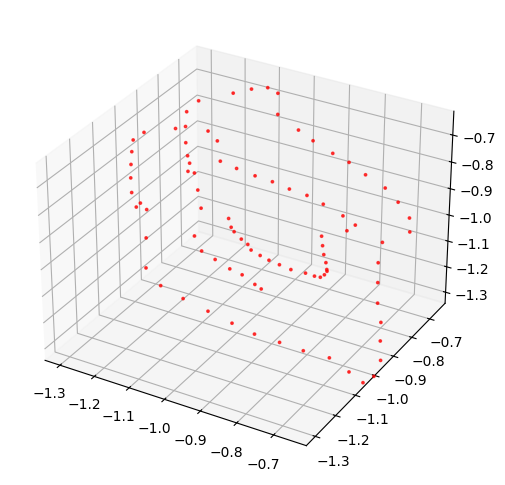

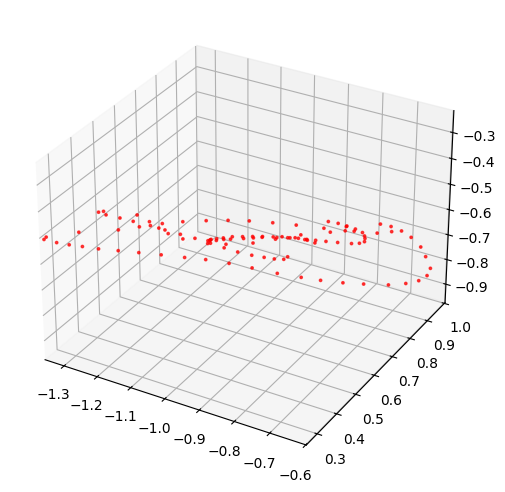

In [12]:
window = 2
plot_3d_points((z_takens[window][:, 0], z_takens[window][:, 1], z_takens[window][:, 2]), figsize=(6, 9))
plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

betti features shape: (115, 300)


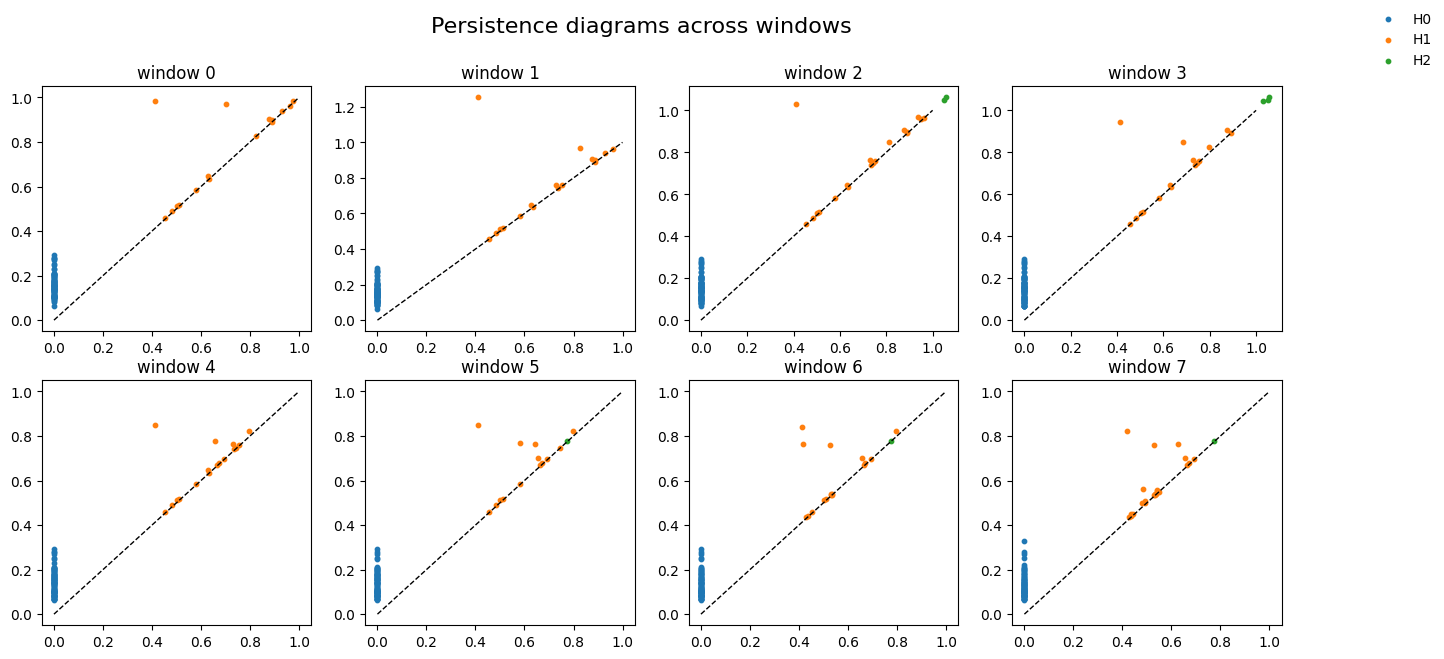

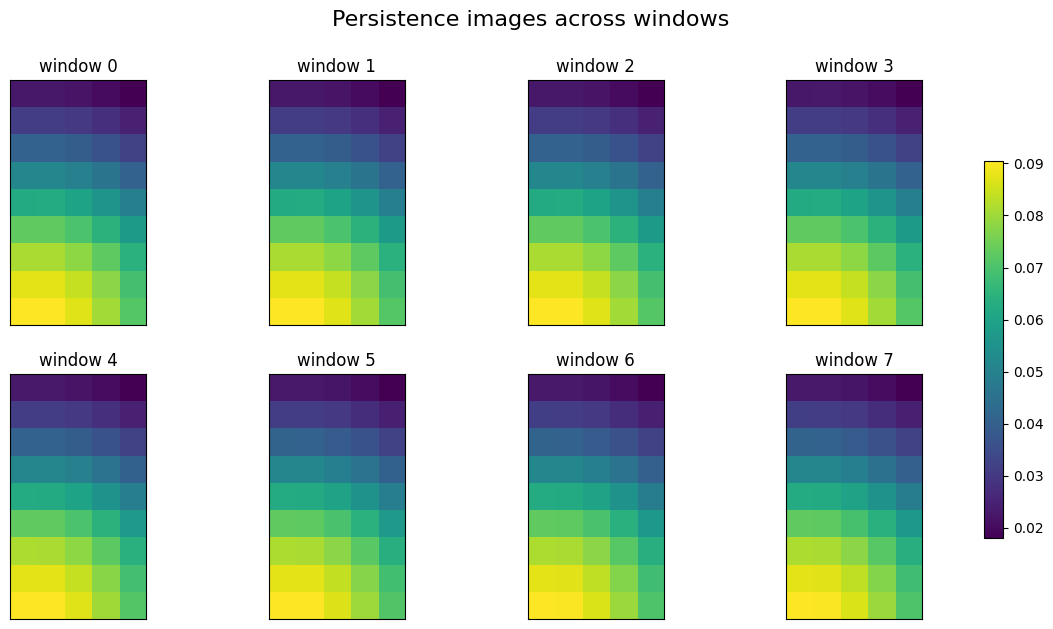

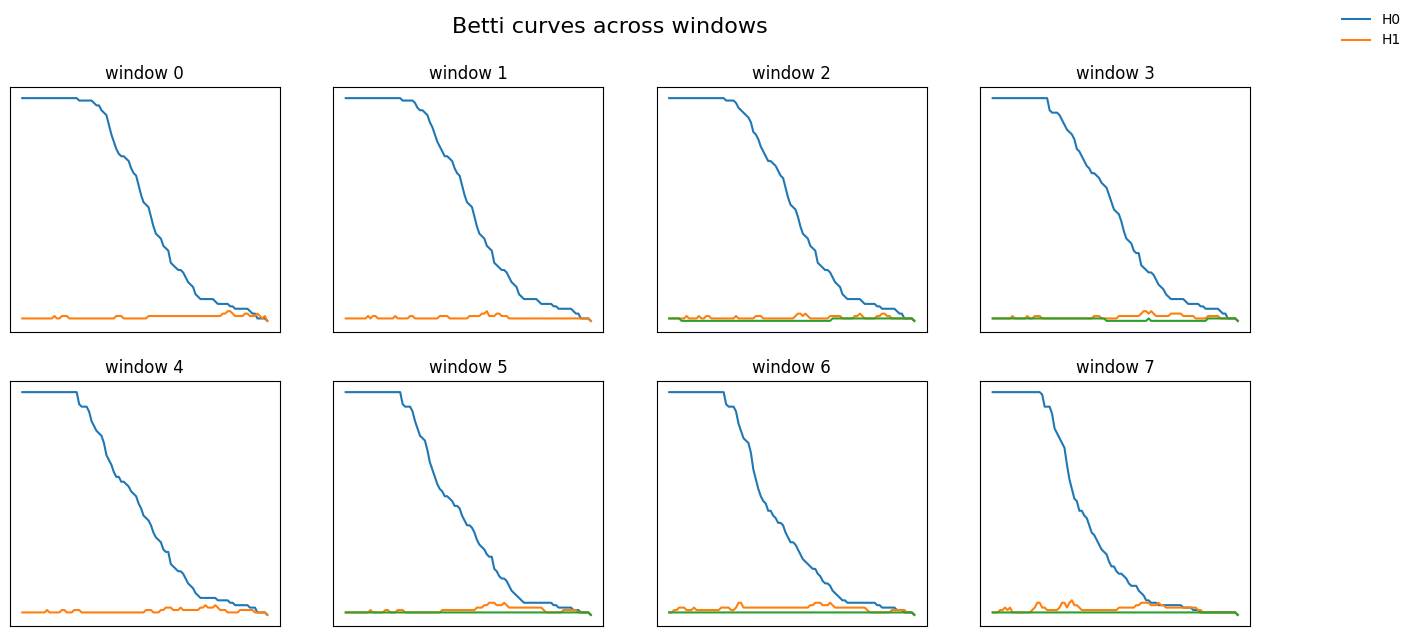

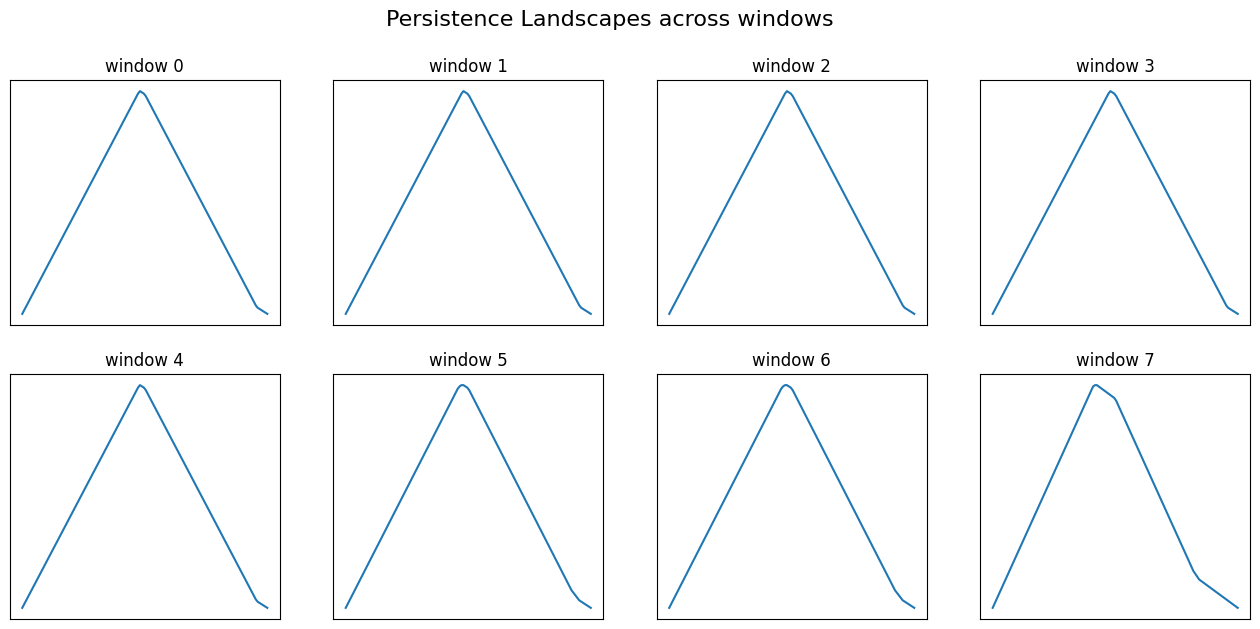

In [13]:

z_betti    = plotter.compute_persistence_features(z_takens, mode="betti")
z_image    = plotter.compute_persistence_features(z_takens, mode="image")
z_diagram  = plotter.compute_persistence_features(z_takens, mode="diagram")
z_landscape= plotter.compute_persistence_features(z_takens, mode="landscape")

print("betti features shape:", z_betti.shape)

plotter.plot_persistence_grid(z_takens)
plotter.plot_persistence_image_grid(z_takens)
plotter.plot_betti_grid(z_takens)
plotter.plot_landscape_grid(z_takens, num_steps=128, K_layers=3)


[1.57e-01 2.87e-01 7.13e-01 8.60e-01 9.90e-01 8.27e-01 1.70e+00 3.03e-01
 2.47e-01 4.80e-01 3.47e-01 4.10e-01 6.07e-01 4.80e-01 5.83e-01 8.63e-01
 3.60e-01 4.07e-01 4.23e-01 5.77e-01 5.57e-01 5.23e-01 2.38e+00 2.63e-01
 6.57e-01 1.30e-01 3.63e-01 2.20e-01 3.93e-01 7.87e-01 7.90e-01 8.03e-01
 4.53e-01 7.40e-01 4.89e+00 3.66e+00 1.02e+00 1.35e+00 4.00e-01 2.30e-01
 2.63e-01 4.20e-01 4.10e-01 4.80e-01 8.70e-01 6.73e-01 9.93e-01 7.30e-01
 2.57e-01 5.17e-01 4.41e+00 1.36e+00 1.11e+00 4.03e-01 1.68e+00 8.10e-01
 4.84e+00 3.65e+00 1.87e+00 3.67e-01 1.83e-01 4.57e-01 6.70e-01 6.27e-01
 7.50e-01 8.20e-01 7.03e-01 5.53e-01 2.27e-01 7.00e-01 7.23e-01 1.12e+00
 3.87e-01 4.10e-01 1.13e-01 2.00e-01 2.40e-01 4.27e-01 3.57e-01 1.37e-01
 7.90e+00 1.00e+00 5.83e-01 1.20e-01 5.73e-01 1.15e+00 7.80e-01 1.14e+00
 5.07e-01 1.97e+00 3.43e-01 3.53e-01 2.93e-01 2.73e-01 3.27e-01 6.57e-01
 9.63e-01 8.47e-01 4.50e-01 4.00e-01 3.03e-01 8.10e-01 6.67e-01 2.53e-01
 5.93e-01 1.76e+00 4.67e-01 2.33e-01 3.93e-01 1.73e

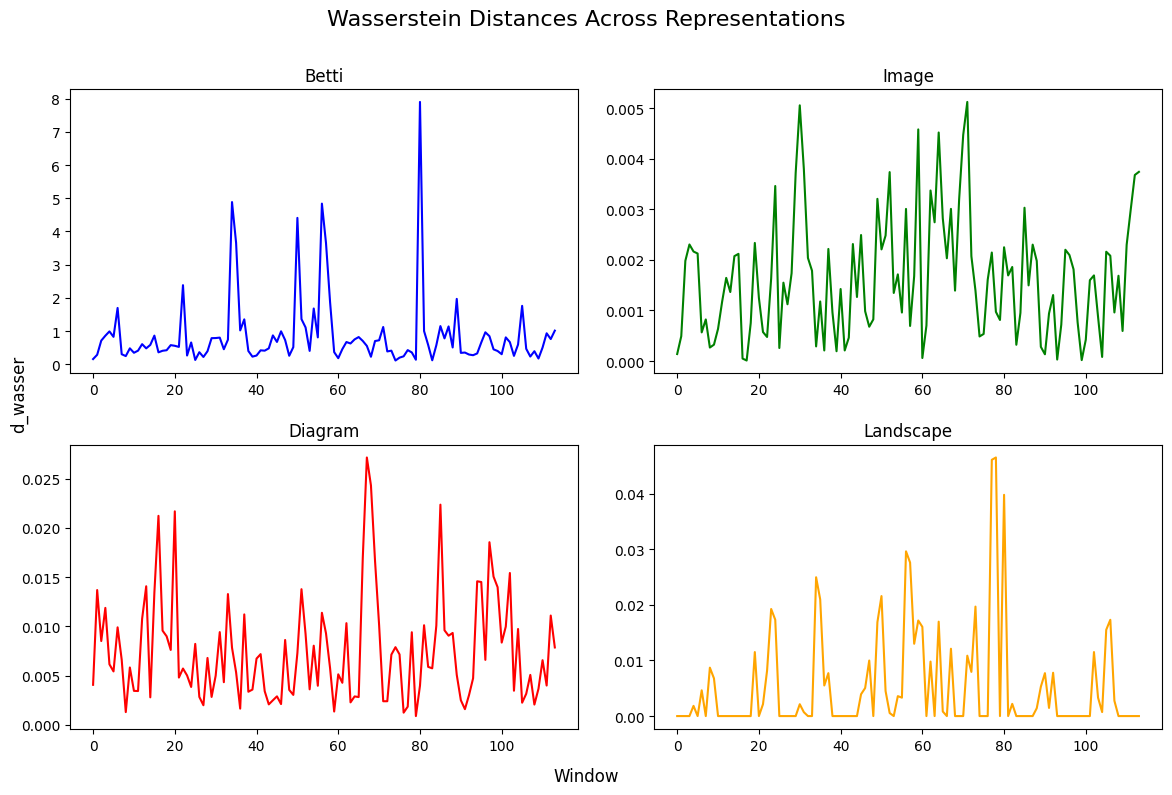

In [19]:

def compute_wasserstein_distances(z_betti, z_image, z_diagram, z_landscape, delay: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """computes Wasserstein distance between consecutive windows for each persistence feature type"""
    betti_dist_array     = np.array([wasserstein_distance(z_betti[i-delay], z_betti[i]) for i in range(delay, z_betti.shape[0])])
    image_dist_array     = np.array([wasserstein_distance(z_image[i-delay], z_image[i]) for i in range(delay, z_image.shape[0])])
    diagram_dist_array   = np.array([wasserstein_distance(z_diagram[i-delay], z_diagram[i]) for i in range(delay, z_diagram.shape[0])])
    landscape_dist_array = np.array([wasserstein_distance(z_landscape[i-delay], z_landscape[i]) for i in range(delay, z_landscape.shape[0])])
    return betti_dist_array, image_dist_array, diagram_dist_array, landscape_dist_array

def plot_all_wasserstein_distances(betti_dist_array, image_dist_array, diagram_dist_array, landscape_dist_array):
    """2x2 grid with global title and shared axis labels."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(betti_dist_array, color='blue')
    axes[0, 0].set_title("Betti")

    axes[0, 1].plot(image_dist_array, color='green')
    axes[0, 1].set_title("Image")

    axes[1, 0].plot(diagram_dist_array, color='red')
    axes[1, 0].set_title("Diagram")

    axes[1, 1].plot(landscape_dist_array, color='orange')
    axes[1, 1].set_title("Landscape")

    fig.suptitle("Wasserstein Distances Across Representations", fontsize=16)
    fig.supxlabel("Window")
    fig.supylabel("d_wasser")

    plt.subplots_adjust(
        left=0.07,
        right=0.98,
        bottom=0.08,
        top=0.88,
        wspace=0.15,
        hspace=0.25)
    plt.show()

betti_dist_array, image_dist_array, diagram_dist_array, landscape_dist_array = \
    compute_wasserstein_distances(z_betti, z_image, z_diagram, z_landscape, delay=1)
# print("d_wasser(betti curves):", betti_dist_array)
# print("d_wasser(persist. image):", image_dist_array)
# print("d_wasser(persist. diagram):", diagram_dist_array)
# print("d_wasser(persist. landscape):", landscape_dist_array)
print(np.array2string(betti_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(image_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(diagram_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(landscape_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))

plot_all_wasserstein_distances(betti_dist_array, image_dist_array, diagram_dist_array, landscape_dist_array)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# =========================
# CONFIG
# =========================
USE_EXOGENOUS = False
N_RUNS = 20
EPOCHS = 50

device = z_train_windows.device
N, L, k = z_train_windows.shape

print(f"Using exogenous: {USE_EXOGENOUS} | Runs: {N_RUNS}")

# =========================
# DATA PREP (fixed)
# =========================
z_in  = z_train_windows[:-1]
y_out = z_train_windows[1:, -1, :]

if USE_EXOGENOUS:
    d = torch.tensor(betti_dist_array, dtype=torch.float32, device=device)
    d = d[:, None, None].expand(-1, L, 1)
    x_in = torch.cat([z_in, d], dim=-1)
    input_dim = k + 1
else:
    x_in = z_in
    input_dim = k

# =========================
# MODEL DEF
# =========================
class ZForecaster(nn.Module):
    """LSTM forecaster"""
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

# =========================
# RUNS
# =========================
mses = []

for run in range(N_RUNS):
    torch.manual_seed(run)

    model = ZForecaster(input_dim=input_dim, hidden_dim=64, output_dim=k).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    loader = DataLoader(TensorDataset(x_in, y_out), batch_size=32, shuffle=True)

    # train
    for epoch in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

    # eval
    model.eval()
    with torch.no_grad():
        pred = model(x_in)
        mse  = loss_fn(pred, y_out).item()

    mses.append(mse)
    print(f"Run {run+1}/{N_RUNS} → MSE: {mse:.6f}")

# =========================
# STATS
# =========================
mean_mse = np.mean(mses)
std_mse  = np.std(mses)

print(f"\nFinal → mean MSE: {mean_mse:.6f}±{std_mse:.6f}")

Using exogenous: False | Runs: 10
Run 1/10 → MSE: 0.028777
Run 2/10 → MSE: 0.021911
Run 3/10 → MSE: 0.015636
Run 4/10 → MSE: 0.009761
Run 5/10 → MSE: 0.031348
Run 6/10 → MSE: 0.030246
Run 7/10 → MSE: 0.030686
Run 8/10 → MSE: 0.010027
Run 9/10 → MSE: 0.011597
Run 10/10 → MSE: 0.011123

Final → mean MSE: 0.020111±0.008951
